In [1]:
import os, random, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T
from torchvision import models
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

In [2]:
class CFG:
    seed = 42
    img_size = 224
    batch_size = 32

    CLASSES = ["akiec","bcc","bkl","df","mel","nv","vasc"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

✅ Device: cuda


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)

In [4]:
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    DRIVE_ROOT = Path.cwd()

RUNS_ROOT = DRIVE_ROOT / "ham_runs"

CNN_RUN_DIR = RUNS_ROOT / "notebook1_cnn_matched_recipe" / "CNN_LADDER_B0_B4"
TL_RUN_DIR  = RUNS_ROOT / "notebook2_transfer_learning_matched_recipe"

print("CNN_RUN_DIR:", CNN_RUN_DIR)
print("TL_RUN_DIR :", TL_RUN_DIR)

assert CNN_RUN_DIR.exists(), "❌ CNN run dir not found"
assert TL_RUN_DIR.exists(),  "❌ TL run dir not found"

Mounted at /content/drive
CNN_RUN_DIR: /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4
TL_RUN_DIR : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe


In [5]:
def resolve_ham10000_paths(search_root: Path):
    csv = list(search_root.rglob("HAM10000_metadata.csv"))[0]
    data_root = csv.parent
    img1 = list(data_root.rglob("HAM10000_images_part_1"))[0]
    img2 = list(data_root.rglob("HAM10000_images_part_2"))[0]
    return csv, img1, img2

CSV_PATH, IMG_DIR1, IMG_DIR2 = resolve_ham10000_paths(DRIVE_ROOT)
print("✅ CSV:", CSV_PATH)

✅ CSV: /content/drive/MyDrive/HAM10000/HAM10000_metadata.csv


In [6]:
df = pd.read_csv(CSV_PATH)

df = df[df["dx"].isin(CFG.CLASSES)].copy()
class_to_idx = {c:i for i,c in enumerate(CFG.CLASSES)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
df["y"] = df["dx"].map(class_to_idx).astype(int)

def build_img_index(img_dir1, img_dir2):
    idx = {}
    for d in [img_dir1, img_dir2]:
        for p in d.glob("*.jpg"):
            idx[p.stem] = p
    return idx

img_index = build_img_index(IMG_DIR1, IMG_DIR2)
df["path"] = df["image_id"].map(lambda k: str(img_index.get(k,"")))
df = df[df["path"]!=""].reset_index(drop=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG.seed)
train_idx, test_idx = next(gss.split(df, groups=df["lesion_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG.seed)
tr_idx, val_idx = next(gss2.split(train_df, groups=train_df["lesion_id"]))

val_df   = train_df.iloc[val_idx].reset_index(drop=True)
train_df = train_df.iloc[tr_idx].reset_index(drop=True)

print("✅ Split:", len(train_df), len(val_df), len(test_df))

✅ Split: 7182 1306 1527


In [7]:
IMAGENET_MEAN = [0.485,0.456,0.406]
IMAGENET_STD  = [0.229,0.224,0.225]

tfm_eval = T.Compose([
    T.Resize((CFG.img_size,CFG.img_size)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class HamDataset(Dataset):
    def __init__(self, df, tfm, return_path=False):
        self.df=df.reset_index(drop=True)
        self.tfm=tfm
        self.return_path=return_path
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        img=Image.open(r["path"]).convert("RGB")
        x=self.tfm(img)
        y=torch.tensor(int(r["y"]),dtype=torch.long)
        return (x,y,r["path"]) if self.return_path else (x,y)

val_loader  = DataLoader(HamDataset(val_df,tfm_eval,True), batch_size=CFG.batch_size, shuffle=False)
test_loader = DataLoader(HamDataset(test_df,tfm_eval,True), batch_size=CFG.batch_size, shuffle=False)

In [8]:
# =========================
# Cell 8 — Load BEST checkpoints from Notebook1 + Notebook2
# =========================
cnn_summary_path = CNN_RUN_DIR / "test_summary.csv"
tl_summary_path  = TL_RUN_DIR  / "test_summary.csv"

assert cnn_summary_path.exists(), f"Missing: {cnn_summary_path}"
assert tl_summary_path.exists(),  f"Missing: {tl_summary_path}"

cnn_sum = pd.read_csv(cnn_summary_path)
tl_sum  = pd.read_csv(tl_summary_path)

# Best by f1 (same rule used in notebook1/2)
best_cnn_row = cnn_sum.sort_values("f1", ascending=False).iloc[0]
best_tl_row  = tl_sum.sort_values("f1", ascending=False).iloc[0]

BEST_CNN_TAG  = str(best_cnn_row["tag"])
BEST_TL_TAG   = str(best_tl_row["tag"])

# Notebook1 saved checkpoints in CNN_RUN_DIR with name best_{tag}.pt
CNN_CKPT = CNN_RUN_DIR / f"best_{BEST_CNN_TAG}.pt"

# Notebook2 saved checkpoints in TL_RUN_DIR with name best_{tag}.pt
TL_CKPT  = TL_RUN_DIR / f"best_{BEST_TL_TAG}.pt"

assert CNN_CKPT.exists(), f"Missing CNN ckpt: {CNN_CKPT}"
assert TL_CKPT.exists(),  f"Missing TL ckpt: {TL_CKPT}"

print("✅ BEST CNN:", BEST_CNN_TAG, "| ckpt:", CNN_CKPT)
print("✅ BEST TL :", BEST_TL_TAG,  "| ckpt:", TL_CKPT)

display(pd.DataFrame([
    {"model":"CNN", "best_tag":BEST_CNN_TAG, "acc":best_cnn_row["acc"], "bacc":best_cnn_row["bacc"], "f1":best_cnn_row["f1"], "loss":best_cnn_row["loss"]},
    {"model":"TL (ResNet50)", "best_tag":BEST_TL_TAG, "acc":best_tl_row["acc"], "bacc":best_tl_row["bacc"], "f1":best_tl_row["f1"], "loss":best_tl_row["loss"]},
]))

✅ BEST CNN: B4_mixup_smooth_ema | ckpt: /content/drive/MyDrive/ham_runs/notebook1_cnn_matched_recipe/CNN_LADDER_B0_B4/best_B4_mixup_smooth_ema.pt
✅ BEST TL : B2_strong_mixup | ckpt: /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B2_strong_mixup.pt


,model,best_tag,acc,bacc,f1,loss
0,CNN,B4_mixup_smooth_ema,0.687623,0.616282,0.714813,0.815193
1,TL (ResNet50),B2_strong_mixup,0.825147,0.778941,0.824182,0.715237


In [9]:
# =========================
# Cell 9 — Define StrongCNN (same as Notebook1) + TLModel (ResNet50)
# =========================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(p)
        )
    def forward(self, x):
        return self.block(x)

class StrongCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32, p=0.10),
            ConvBlock(32,  64, p=0.15),
            ConvBlock(64, 128, p=0.20),
            ConvBlock(128,256, p=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

class TLModel(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        backbone = models.resnet50(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Linear(in_features, num_classes)

        # Disable inplace ReLU (prevents Grad-CAM hook issues)
        for m in self.backbone.modules():
            if isinstance(m, nn.ReLU):
                m.inplace = False

        # Best Grad-CAM layer for ResNet50
        self.cam_target = self.backbone.layer4[-1].conv3

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

print("✅ Models defined.")

✅ Models defined.


In [10]:
# =========================
# Cell 10 — Load checkpoints + make Grad-CAM safe
# =========================
def load_ckpt(model, ckpt_path: Path):
    sd = torch.load(str(ckpt_path), map_location=device)
    model.load_state_dict(sd, strict=True)
    return model

def disable_inplace_relu(model: nn.Module):
    # Important for StrongCNN too (Grad-CAM stability)
    for m in model.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = False

cnn_model = StrongCNN(len(CFG.CLASSES)).to(device)
cnn_model = load_ckpt(cnn_model, CNN_CKPT)
disable_inplace_relu(cnn_model)
cnn_model.eval()

tl_model = TLModel(len(CFG.CLASSES), pretrained=True).to(device)
tl_model = load_ckpt(tl_model, TL_CKPT)
tl_model.eval()

print("✅ Loaded CNN:", BEST_CNN_TAG)
print("✅ Loaded TL :", BEST_TL_TAG)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


✅ Loaded CNN: B4_mixup_smooth_ema
✅ Loaded TL : B2_strong_mixup


In [11]:
# =========================
# Cell 11 — Evaluation helpers
# =========================
@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    all_y, all_p, all_probs, all_paths = [], [], [], []
    for x, y, p in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = probs.argmax(axis=1)

        all_probs.append(probs)
        all_p.append(pred)
        all_y.append(y.numpy())
        all_paths.extend(list(p))

    all_probs = np.concatenate(all_probs, axis=0)
    all_p     = np.concatenate(all_p, axis=0)
    all_y     = np.concatenate(all_y, axis=0)
    return all_y, all_p, all_probs, np.array(all_paths)

def metrics_from_preds(y_true, y_pred):
    acc  = float((y_true == y_pred).mean())
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    f1  = float(f1_score(y_true, y_pred, average="weighted"))
    cm   = confusion_matrix(y_true, y_pred)
    return acc, bacc, f1, cm

def plot_cm(cm, title, labels):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

print("✅ Eval helpers ready.")

✅ Eval helpers ready.



✅ BEST CNN  : B4_mixup_smooth_ema
acc=0.6876 | bacc=0.6163 | f1=0.7148
              precision    recall  f1-score   support

       akiec     0.2756    0.7292    0.4000        48
         bcc     0.4706    0.6061    0.5298        66
         bkl     0.5600    0.4884    0.5217       172
          df     0.2105    0.4000    0.2759        10
         mel     0.3824    0.6290    0.4756       186
          nv     0.9398    0.7372    0.8263      1016
        vasc     0.4884    0.7241    0.5833        29

    accuracy                         0.6876      1527
   macro avg     0.4753    0.6163    0.5161      1527
weighted avg     0.7746    0.6876    0.7148      1527


✅ BEST TL   : ResNet50 | B2_strong_mixup
acc=0.8251 | bacc=0.7789 | f1=0.8242
              precision    recall  f1-score   support

       akiec     0.4677    0.6042    0.5273        48
         bcc     0.6667    0.7576    0.7092        66
         bkl     0.7239    0.6860    0.7045       172
          df     0.8333    1.0000  

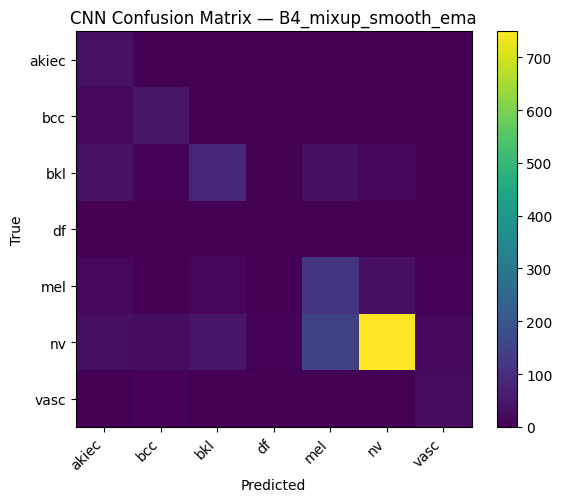

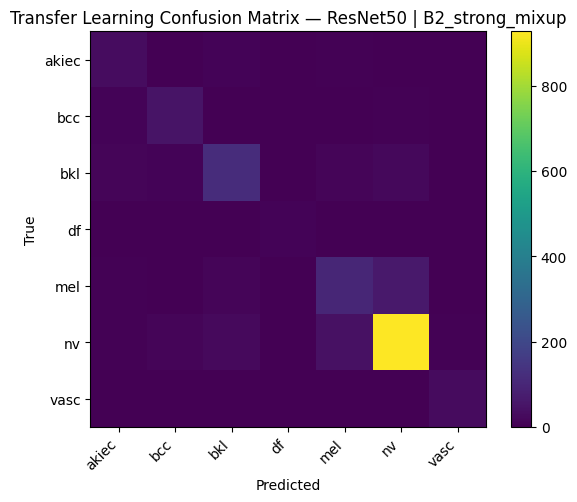

,model,tag,acc,bacc,f1
0,CNN,B4_mixup_smooth_ema,0.687623,0.616282,0.714813
1,TL (ResNet50),B2_strong_mixup,0.825147,0.778941,0.824182


In [12]:
# =========================
# Cell 12 — TEST evaluation (CNN vs TL)
# =========================
y_cnn, p_cnn, probs_cnn, paths_test = predict_probs(cnn_model, test_loader)
y_tl,  p_tl,  probs_tl,  _         = predict_probs(tl_model,  test_loader)

assert np.all(y_cnn == y_tl), "❌ Mismatch in test order/labels (should never happen)."
y_test = y_cnn

cnn_acc, cnn_bacc, cnn_f1, cnn_cm = metrics_from_preds(y_test, p_cnn)
tl_acc,  tl_bacc,  tl_f1,  tl_cm  = metrics_from_preds(y_test, p_tl)

print("\n" + "="*100)
print(f"✅ BEST CNN  : {BEST_CNN_TAG}")
print("="*100)
print(f"acc={cnn_acc:.4f} | bacc={cnn_bacc:.4f} | f1={cnn_f1:.4f}")
print(classification_report(y_test, p_cnn, target_names=CFG.CLASSES, digits=4))

print("\n" + "="*100)
print(f"✅ BEST TL   : ResNet50 | {BEST_TL_TAG}")
print("="*100)
print(f"acc={tl_acc:.4f} | bacc={tl_bacc:.4f} | f1={tl_f1:.4f}")
print(classification_report(y_test, p_tl, target_names=CFG.CLASSES, digits=4))

plot_cm(cnn_cm, f"CNN Confusion Matrix — {BEST_CNN_TAG}", CFG.CLASSES)
plot_cm(tl_cm,  f"Transfer Learning Confusion Matrix — ResNet50 | {BEST_TL_TAG}", CFG.CLASSES)

display(pd.DataFrame([
    {"model":"CNN", "tag":BEST_CNN_TAG, "acc":cnn_acc, "bacc":cnn_bacc, "f1":cnn_f1},
    {"model":"TL (ResNet50)", "tag":BEST_TL_TAG, "acc":tl_acc, "bacc":tl_bacc, "f1":tl_f1},
]))

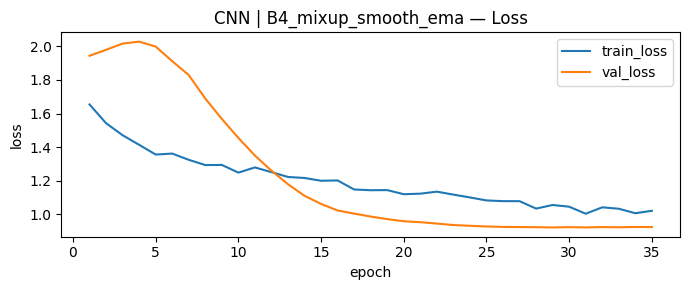

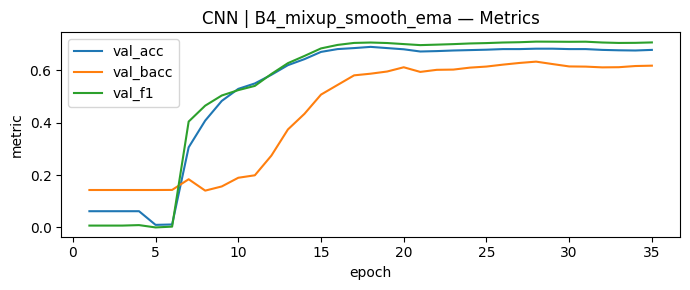

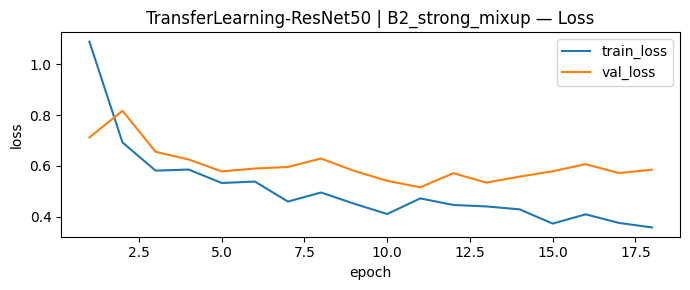

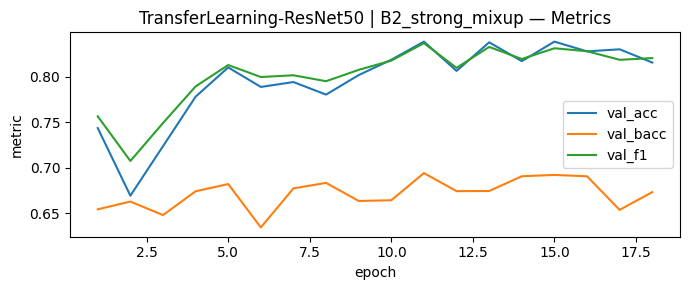

In [13]:
# =========================
# Cell 13 — Load + plot training curves for BEST CNN and BEST TL
# =========================
def plot_history_csv(hist_csv: Path, title: str):
    assert hist_csv.exists(), f"Missing history: {hist_csv}"
    h = pd.read_csv(hist_csv)

    # loss
    plt.figure(figsize=(7,3))
    plt.plot(h["epoch"], h["train_loss"], label="train_loss")
    plt.plot(h["epoch"], h["val_loss"],   label="val_loss")
    plt.title(f"{title} — Loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(); plt.tight_layout(); plt.show()

    # metrics
    plt.figure(figsize=(7,3))
    plt.plot(h["epoch"], h["val_acc"],      label="val_acc")
    plt.plot(h["epoch"], h["val_bacc"],     label="val_bacc")
    plt.plot(h["epoch"], h["val_f1"], label="val_f1")
    plt.title(f"{title} — Metrics")
    plt.xlabel("epoch"); plt.ylabel("metric")
    plt.legend(); plt.tight_layout(); plt.show()

cnn_hist = CNN_RUN_DIR / f"history_{BEST_CNN_TAG}.csv"
tl_hist  = TL_RUN_DIR  / f"history_{BEST_TL_TAG}.csv"

plot_history_csv(cnn_hist, f"CNN | {BEST_CNN_TAG}")
plot_history_csv(tl_hist,  f"TransferLearning-ResNet50 | {BEST_TL_TAG}")

✅ Best alpha on VAL: 0.2


,alpha,val_acc,val_bacc,val_f1
4,0.20,0.838438,0.696831,0.837695
1,0.05,0.839204,0.695152,0.837665
3,0.15,0.838438,0.696831,0.837611
2,0.10,0.838438,0.695885,0.837250
0,0.00,0.838438,0.694045,0.836757
5,0.25,0.836907,0.694905,0.836537
7,0.35,0.834609,0.694178,0.834149
6,0.30,0.833844,0.692414,0.833471
8,0.40,0.833844,0.693071,0.833292
10,0.50,0.832312,0.701427,0.832816



✅ HYBRID (CNN + TL) — alpha=0.20
acc=0.8265 | bacc=0.7839 | f1=0.8258
              precision    recall  f1-score   support

       akiec     0.4677    0.6042    0.5273        48
         bcc     0.6753    0.7879    0.7273        66
         bkl     0.7195    0.6860    0.7024       172
          df     0.8333    1.0000    0.9091        10
         mel     0.6149    0.5323    0.5706       186
          nv     0.9150    0.9114    0.9132      1016
        vasc     0.7179    0.9655    0.8235        29

    accuracy                         0.8265      1527
   macro avg     0.7063    0.7839    0.7391      1527
weighted avg     0.8277    0.8265    0.8258      1527



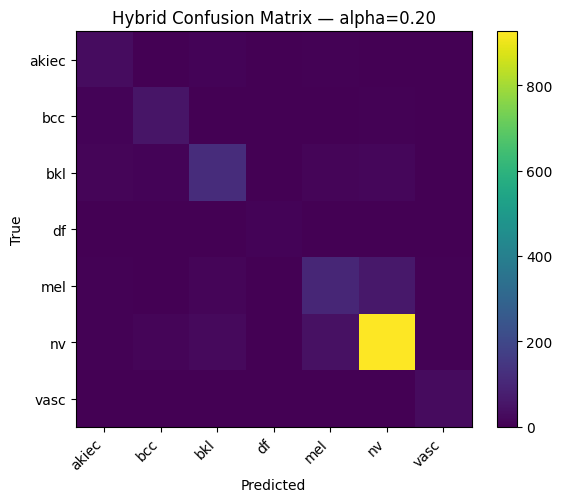

,model,tag,acc,bacc,f1
2,HYBRID,alpha=0.20,0.826457,0.783898,0.825836
1,TL (ResNet50),B2_strong_mixup,0.825147,0.778941,0.824182
0,CNN,B4_mixup_smooth_ema,0.687623,0.616282,0.714813


In [14]:
# =========================
# Cell 14 — Hybrid ensemble (soft voting)
#   probs_hybrid = alpha * probs_CNN + (1-alpha) * probs_TL
#   alpha chosen on VAL (fair: no test leakage)
# =========================
yV_cnn, _, probsV_cnn, paths_val = predict_probs(cnn_model, val_loader)
yV_tl,  _, probsV_tl,  _         = predict_probs(tl_model,  val_loader)
assert np.all(yV_cnn == yV_tl)
y_val = yV_cnn

def hybrid_eval(probsA, probsB, y_true, alpha: float):
    probsH = alpha * probsA + (1.0 - alpha) * probsB
    predH = probsH.argmax(axis=1)
    acc, bacc, f1, cm = metrics_from_preds(y_true, predH)
    return acc, bacc, f1, cm, predH, probsH

alphas = np.linspace(0.0, 1.0, 21)  # 0.00 .. 1.00
rows = []
best_alpha = None
best_score = -1

for a in alphas:
    acc, bacc, f1, _, _, _ = hybrid_eval(probsV_cnn, probsV_tl, y_val, float(a))
    # choose by f1 (your main ranking), tie-breaker by bacc
    score = f1 + 0.001*bacc
    rows.append({"alpha": float(a), "val_acc": acc, "val_bacc": bacc, "val_f1": f1})
    if score > best_score:
        best_score = score
        best_alpha = float(a)

grid_df = pd.DataFrame(rows).sort_values("val_f1", ascending=False)
print("✅ Best alpha on VAL:", best_alpha)
display(grid_df)

# Evaluate hybrid on TEST using best_alpha
hy_acc, hy_bacc, hy_f1, hy_cm, hy_pred, hy_probs = hybrid_eval(probs_cnn, probs_tl, y_test, best_alpha)

print("\n" + "="*100)
print(f"✅ HYBRID (CNN + TL) — alpha={best_alpha:.2f}")
print("="*100)
print(f"acc={hy_acc:.4f} | bacc={hy_bacc:.4f} | f1={hy_f1:.4f}")
print(classification_report(y_test, hy_pred, target_names=CFG.CLASSES, digits=4))
plot_cm(hy_cm, f"Hybrid Confusion Matrix — alpha={best_alpha:.2f}", CFG.CLASSES)

display(pd.DataFrame([
    {"model":"CNN", "tag":BEST_CNN_TAG, "acc":cnn_acc, "bacc":cnn_bacc, "f1":cnn_f1},
    {"model":"TL (ResNet50)", "tag":BEST_TL_TAG, "acc":tl_acc, "bacc":tl_bacc, "f1":tl_f1},
    {"model":"HYBRID", "tag":f"alpha={best_alpha:.2f}", "acc":hy_acc, "bacc":hy_bacc, "f1":hy_f1},
]).sort_values("f1", ascending=False))


## Final Analysis, Hybrid Curves, Grad-CAM, and Manual Testing

The following cells extend the notebook with:

- **Hybrid validation curves** (CNN vs TL vs HYBRID)
- **Final report summary** saved to CSV
- **Professional Grad-CAM** for the **same images** across CNN, TL, and HYBRID
- **Manual testing** with Grad-CAM for CNN, TL, and HYBRID


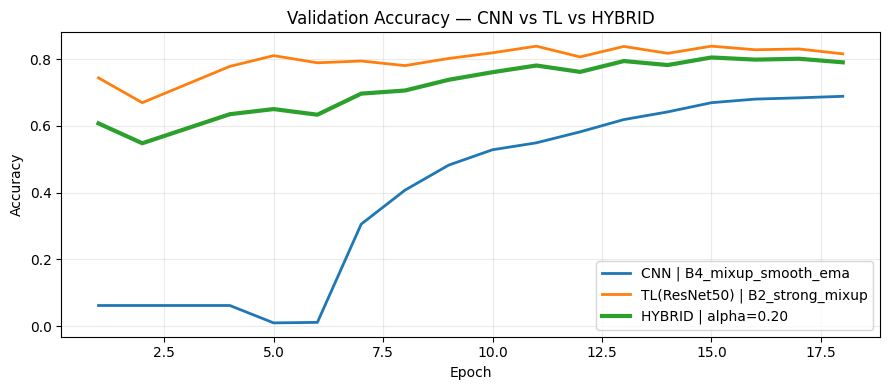

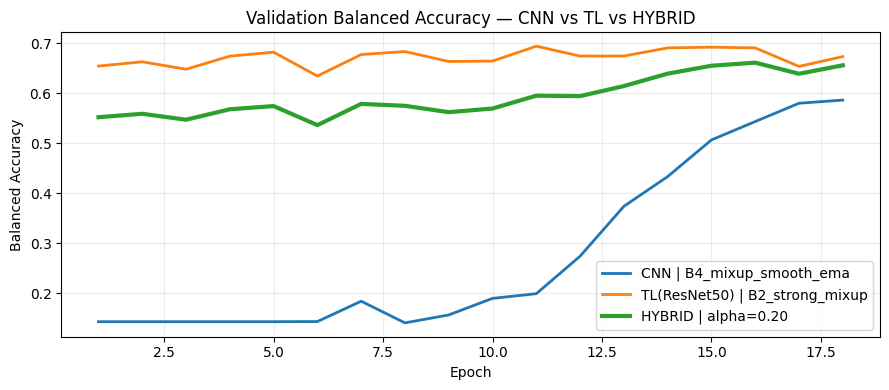

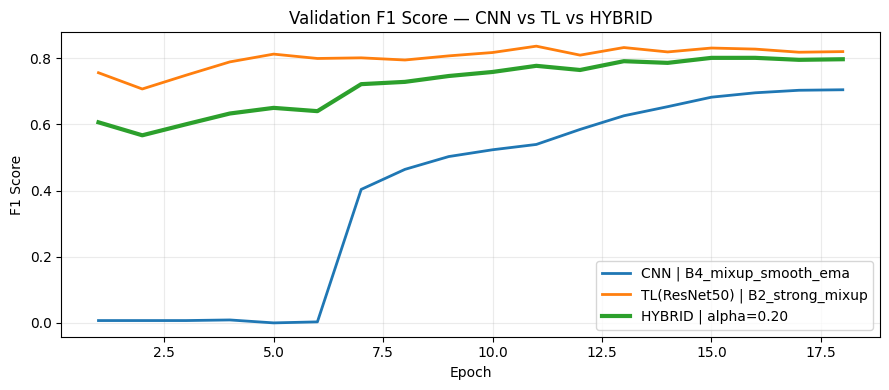

✅ Hybrid validation curves ready.


In [15]:

# =========================
# Cell 15 — Hybrid validation curves (CNN vs TL vs HYBRID)
#   Note: HYBRID is not trained epoch-by-epoch, so we visualise an
#   epoch-wise fused validation curve using the same best alpha.
# =========================
cnn_hist = pd.read_csv(CNN_RUN_DIR / f"history_{BEST_CNN_TAG}.csv")
tl_hist  = pd.read_csv(TL_RUN_DIR  / f"history_{BEST_TL_TAG}.csv")

n_epochs = min(len(cnn_hist), len(tl_hist))
cnn_hist = cnn_hist.iloc[:n_epochs].copy()
tl_hist  = tl_hist.iloc[:n_epochs].copy()

alpha = float(best_alpha)

hy_val_acc  = alpha * cnn_hist["val_acc"].values      + (1.0 - alpha) * tl_hist["val_acc"].values
hy_val_bacc = alpha * cnn_hist["val_bacc"].values     + (1.0 - alpha) * tl_hist["val_bacc"].values
hy_val_f1   = alpha * cnn_hist["val_f1"].values + (1.0 - alpha) * tl_hist["val_f1"].values

epochs = cnn_hist["epoch"].values

def _plot_three(y1, y2, y3, label1, label2, label3, title, ylabel):
    plt.figure(figsize=(9,4))
    plt.plot(epochs, y1, label=label1, linewidth=2)
    plt.plot(epochs, y2, label=label2, linewidth=2)
    plt.plot(epochs, y3, label=label3, linewidth=3)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

_plot_three(
    cnn_hist["val_acc"].values, tl_hist["val_acc"].values, hy_val_acc,
    f"CNN | {BEST_CNN_TAG}",
    f"TL(ResNet50) | {BEST_TL_TAG}",
    f"HYBRID | alpha={alpha:.2f}",
    "Validation Accuracy — CNN vs TL vs HYBRID",
    "Accuracy",
)

_plot_three(
    cnn_hist["val_bacc"].values, tl_hist["val_bacc"].values, hy_val_bacc,
    f"CNN | {BEST_CNN_TAG}",
    f"TL(ResNet50) | {BEST_TL_TAG}",
    f"HYBRID | alpha={alpha:.2f}",
    "Validation Balanced Accuracy — CNN vs TL vs HYBRID",
    "Balanced Accuracy",
)

_plot_three(
    cnn_hist["val_f1"].values, tl_hist["val_f1"].values, hy_val_f1,
    f"CNN | {BEST_CNN_TAG}",
    f"TL(ResNet50) | {BEST_TL_TAG}",
    f"HYBRID | alpha={alpha:.2f}",
    "Validation F1 Score — CNN vs TL vs HYBRID",
    "F1 Score",
)

print("✅ Hybrid validation curves ready.")


In [16]:

# =========================
# Cell 16 — Save final comparison summary (report-friendly)
# =========================
final_summary = pd.DataFrame([
    {"model":"CNN", "name":"StrongCNN", "tag":BEST_CNN_TAG, "acc":cnn_acc, "bacc":cnn_bacc, "f1":cnn_f1, "source":"Notebook 1"},
    {"model":"TL",  "name":"ResNet50",  "tag":BEST_TL_TAG,  "acc":tl_acc,  "bacc":tl_bacc,  "f1":tl_f1,  "source":"Notebook 2"},
    {"model":"HYBRID", "name":"CNN + ResNet50", "tag":f"alpha={best_alpha:.2f}", "acc":hy_acc, "bacc":hy_bacc, "f1":hy_f1, "source":"Notebook 3"},
]).sort_values("f1", ascending=False).reset_index(drop=True)

display(final_summary)

final_csv = RUNS_ROOT / "notebook3_final_report_summary.csv"
final_summary.to_csv(final_csv, index=False)
print("✅ Saved final summary:", final_csv)


,model,name,tag,acc,bacc,f1,source
0,HYBRID,CNN + ResNet50,alpha=0.20,0.826457,0.783898,0.825836,Notebook 3
1,TL,ResNet50,B2_strong_mixup,0.825147,0.778941,0.824182,Notebook 2
2,CNN,StrongCNN,B4_mixup_smooth_ema,0.687623,0.616282,0.714813,Notebook 1


✅ Saved final summary: /content/drive/MyDrive/ham_runs/notebook3_final_report_summary.csv


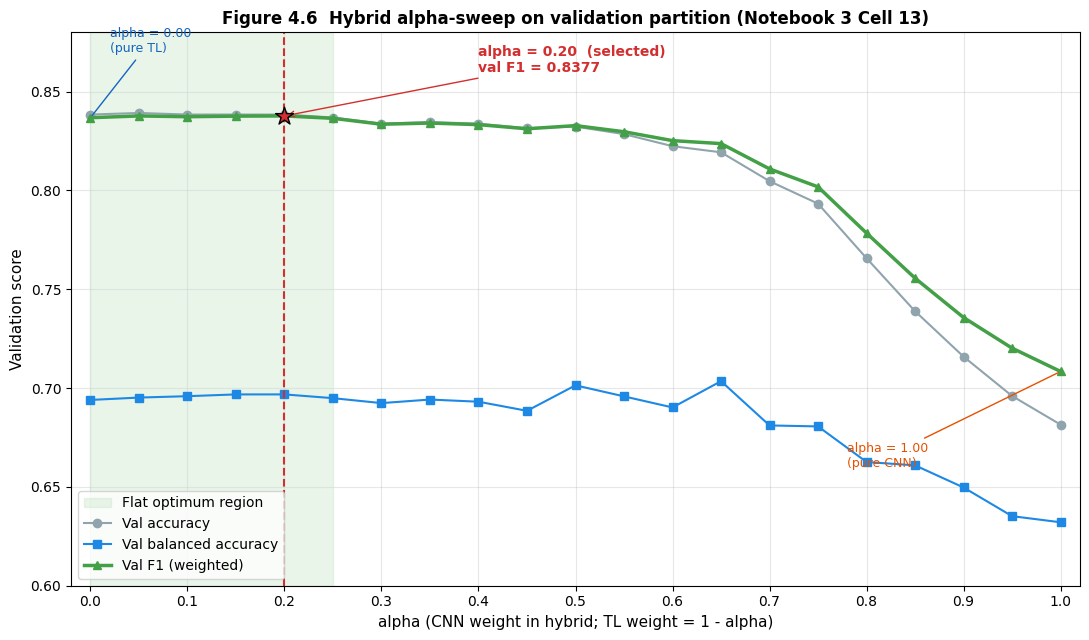

In [ ]:
# Figure 4.6 — Hybrid alpha-sweep curve
import numpy as np
import matplotlib.pyplot as plt

alpha    = np.arange(0.00, 1.01, 0.05)

# ---- VERIFIED Notebook 3 Cell 13 ----
val_acc  = [0.8384, 0.8392, 0.8384, 0.8384, 0.8384, 0.8369, 0.8338, 0.8346,
            0.8338, 0.8315, 0.8323, 0.8285, 0.8224, 0.8193, 0.8047, 0.7933,
            0.7657, 0.7389, 0.7159, 0.6960, 0.6815]
val_bacc = [0.6940, 0.6952, 0.6959, 0.6968, 0.6968, 0.6949, 0.6924, 0.6942,
            0.6931, 0.6885, 0.7014, 0.6958, 0.6902, 0.7035, 0.6811, 0.6806,
            0.6626, 0.6609, 0.6497, 0.6352, 0.6321]
val_f1   = [0.8368, 0.8377, 0.8373, 0.8376, 0.8377, 0.8365, 0.8335, 0.8341,
            0.8333, 0.8312, 0.8328, 0.8297, 0.8252, 0.8237, 0.8109, 0.8018,
            0.7784, 0.7556, 0.7357, 0.7202, 0.7084]

fig, ax = plt.subplots(figsize=(11, 6.5))

# Shade flat region
ax.axvspan(0.00, 0.25, color='#C8E6C9', alpha=0.4,
           label='Flat optimum region')

ax.plot(alpha, val_acc,  marker='o', label='Val accuracy',         color='#90A4AE')
ax.plot(alpha, val_bacc, marker='s', label='Val balanced accuracy', color='#1E88E5')
ax.plot(alpha, val_f1,   marker='^', label='Val F1 (weighted)',     color='#43A047',
        linewidth=2.5)

# Selected alpha
ax.axvline(x=0.20, color='#D32F2F', linestyle='--', linewidth=1.5)
ax.scatter([0.20], [0.8377], color='#D32F2F', s=180,
           zorder=5, marker='*', edgecolor='black')
ax.annotate('alpha = 0.20  (selected)\nval F1 = 0.8377',
            xy=(0.20, 0.8377), xytext=(0.40, 0.86), fontsize=10,
            color='#D32F2F', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D32F2F'))

# Endpoint annotations
ax.annotate('alpha = 0.00\n(pure TL)',  xy=(0.00, 0.8368), xytext=(0.02, 0.87),
            fontsize=9, color='#1565C0',
            arrowprops=dict(arrowstyle='-', color='#1565C0'))
ax.annotate('alpha = 1.00\n(pure CNN)', xy=(1.00, 0.7084), xytext=(0.78, 0.66),
            fontsize=9, color='#E65100',
            arrowprops=dict(arrowstyle='-', color='#E65100'))

ax.set_xlabel('alpha (CNN weight in hybrid; TL weight = 1 - alpha)', fontsize=11)
ax.set_ylabel('Validation score', fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0.60, 0.88)
ax.set_xticks(np.arange(0, 1.05, 0.10))
ax.set_title('Figure 4.6  Hybrid alpha-sweep on validation partition (Notebook 3 Cell 13)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('Figure_4_6_alpha_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# ============================================================
# CELL A — Test-split case-study selection (Table 4.10)
# ============================================================
import numpy as np
import pandas as pd
import os

CLASSES = CFG.CLASSES   # ['akiec','bcc','bkl','df','mel','nv','vasc']

# ---- correctness flags per model (in-distribution test split) ----
cnn_correct = (p_cnn  == y_test)
tl_correct  = (p_tl   == y_test)
hy_correct  = (hy_pred == y_test)

# ---- per-row confidence of the predicted class ----
conf_cnn = probs_cnn[np.arange(len(y_test)), p_cnn]
conf_tl  = probs_tl [np.arange(len(y_test)), p_tl ]
conf_hy  = hy_probs [np.arange(len(y_test)), hy_pred]

# ---- pattern label ----
def pattern_label(c, t, h):
    code = (int(c), int(t), int(h))
    return {
        (1,1,1): 'all three correct',
        (0,1,1): 'CNN wrong; TL & Hybrid correct',
        (1,0,0): 'CNN correct; TL & Hybrid wrong',
        (1,1,0): 'CNN & TL correct; Hybrid wrong',
        (0,0,1): 'Hybrid only correct',
        (1,0,1): 'CNN & Hybrid correct; TL wrong',
        (0,1,0): 'TL only correct',
        (0,0,0): 'all three wrong',
    }[code]

patterns = np.array([pattern_label(c, t, h)
                     for c, t, h in zip(cnn_correct, tl_correct, hy_correct)])

# ---- master DataFrame (one row per test image) ----
master = pd.DataFrame({
    'idx'             : np.arange(len(y_test)),
    'image_id'        : test_df['image_id'].values,
    'path'            : test_df['path'].values,
    'ground_truth_dx' : test_df['dx'].values,
    'y_true'          : y_test,
    'cnn_pred_idx'    : p_cnn,
    'tl_pred_idx'     : p_tl,
    'hy_pred_idx'     : hy_pred,
    'cnn_conf'        : conf_cnn,
    'tl_conf'         : conf_tl,
    'hy_conf'         : conf_hy,
    'cnn_correct'     : cnn_correct.astype(int),
    'tl_correct'      : tl_correct.astype(int),
    'hy_correct'      : hy_correct.astype(int),
    'pattern'         : patterns,
})

master['cnn_pred'] = [CLASSES[i] for i in master['cnn_pred_idx']]
master['tl_pred']  = [CLASSES[i] for i in master['tl_pred_idx']]
master['hy_pred']  = [CLASSES[i] for i in master['hy_pred_idx']]
master['models_disagree']     = (master['cnn_pred_idx'] != master['tl_pred_idx']).astype(int)
master['high_conf_disagree']  = (
    master['models_disagree'] &
    (master['cnn_conf'] >= 0.50) & (master['tl_conf'] >= 0.50)
)

# ---- selection helpers ----
def first_or_none(df, **filters):
    """Return first row matching all key=value filters, or None."""
    sub = df.copy()
    for k, v in filters.items():
        sub = sub[sub[k] == v]
    if len(sub) == 0:
        return None
    return sub.iloc[0]

def highest_disagreement(df):
    """Highest-confidence model disagreement."""
    sub = df[df['high_conf_disagree'] == 1].copy()
    if len(sub) == 0:
        sub = df[df['models_disagree'] == 1].copy()
    if len(sub) == 0:
        return None
    sub['joint_conf'] = sub[['cnn_conf', 'tl_conf']].min(axis=1)
    return sub.sort_values('joint_conf', ascending=False).iloc[0]

def same_class_diff_conf(df):
    """All three predict the same class, with the largest confidence spread."""
    sub = df[(df['cnn_pred_idx'] == df['tl_pred_idx']) &
             (df['cnn_pred_idx'] == df['hy_pred_idx'])].copy()
    if len(sub) == 0:
        return None
    sub['conf_spread'] = sub[['cnn_conf', 'tl_conf', 'hy_conf']].max(axis=1) - \
                         sub[['cnn_conf', 'tl_conf', 'hy_conf']].min(axis=1)
    return sub.sort_values('conf_spread', ascending=False).iloc[0]

def minority_example(df, minorities=('df', 'vasc', 'akiec')):
    """First held-out image with a minority-class ground truth."""
    for cls in minorities:
        row = first_or_none(df, ground_truth_dx=cls)
        if row is not None:
            return row
    return None

# ---- selection: 6 rows, defensive fallbacks ----
selected_rows  = []
selected_idxs  = set()
selection_log  = []

def add_row(row, label):
    if row is None:
        selection_log.append(f"  -- skipped (no match): {label}")
        return False
    if int(row['idx']) in selected_idxs:
        selection_log.append(f"  -- already chosen, looking again: {label}")
        return False
    selected_rows.append(row)
    selected_idxs.add(int(row['idx']))
    selection_log.append(f"  ok  {label}: idx={int(row['idx'])} "
                         f"id={row['image_id']} dx={row['ground_truth_dx']}")
    return True

# slot 1 — all three correct (prefer minority dx so the figure is interesting)
slot1 = master[
    (master['cnn_correct'] == 1) &
    (master['tl_correct'] == 1) &
    (master['hy_correct'] == 1)
].copy()
slot1 = slot1.sort_values(['ground_truth_dx', 'hy_conf'],
                          key=lambda s: s.map({'df':0, 'vasc':1, 'akiec':2,
                                               'bcc':3, 'bkl':4, 'mel':5, 'nv':6})
                          if s.name == 'ground_truth_dx' else -s)
row1 = slot1.iloc[0] if len(slot1) else None
add_row(row1, "all three correct")

# slot 2 — CNN wrong, TL & Hybrid correct
add_row(first_or_none(master, cnn_correct=0, tl_correct=1, hy_correct=1),
        "CNN wrong; TL & Hybrid correct")

# slot 3 — CNN correct, TL & Hybrid wrong
add_row(first_or_none(master, cnn_correct=1, tl_correct=0, hy_correct=0),
        "CNN correct; TL & Hybrid wrong")

# slot 4 — same prediction class, biggest confidence spread
add_row(same_class_diff_conf(master),
        "same prediction class, different confidences")

# slot 5 — high-confidence disagreement
add_row(highest_disagreement(master),
        "high-confidence disagreement")

# slot 6 — minority-class ground truth
mr = minority_example(master)
if mr is not None and int(mr['idx']) in selected_idxs:
    # if already covered, pick a different minority example
    for cls in ('df', 'vasc', 'akiec'):
        cands = master[(master['ground_truth_dx'] == cls) &
                       (~master['idx'].isin(selected_idxs))]
        if len(cands):
            mr = cands.iloc[0]; break
add_row(mr, "minority-class ground truth")

print("Selection log:")
print('\n'.join(selection_log))

# ---- build human-readable comparison table ----
def fmt_pred(name, conf): return f"{name} ({conf*100:.1f}%)"

table_rows = []
for r in selected_rows:
    table_rows.append({
        'image_id'         : r['image_id'],
        'ground_truth_dx'  : r['ground_truth_dx'],
        'cnn'              : fmt_pred(r['cnn_pred'], r['cnn_conf']),
        'tl'               : fmt_pred(r['tl_pred'],  r['tl_conf']),
        'hybrid'           : fmt_pred(r['hy_pred'],  r['hy_conf']),
        'pattern'          : r['pattern'],
    })

comparison_df = pd.DataFrame(table_rows)
print("\nTable 4.10 — Test-split Grad-CAM case studies:")
print(comparison_df.to_string(index=False))

OUT_DIR = '/content'
csv_path = os.path.join(OUT_DIR, 'Table_4_10_test_split_gradcam_predictions.csv')
comparison_df.to_csv(csv_path, index=False)
print(f"\nSaved CSV: {csv_path}")

Selection log:
  ok  all three correct: idx=179 id=ISIC_0025911 dx=df
  ok  CNN wrong; TL & Hybrid correct: idx=9 id=ISIC_0027960 dx=bkl
  ok  CNN correct; TL & Hybrid wrong: idx=47 id=ISIC_0028336 dx=bkl
  ok  same prediction class, different confidences: idx=1243 id=ISIC_0029775 dx=nv
  ok  high-confidence disagreement: idx=394 id=ISIC_0025250 dx=vasc
  ok  minority-class ground truth: idx=171 id=ISIC_0032642 dx=df

Table 4.10 — Test-split Grad-CAM case studies:
    image_id ground_truth_dx           cnn           tl       hybrid                        pattern
ISIC_0025911              df    df (75.2%)   df (94.0%)   df (90.2%)              all three correct
ISIC_0027960             bkl akiec (44.7%)  bkl (90.3%)  bkl (76.5%) CNN wrong; TL & Hybrid correct
ISIC_0028336             bkl   bkl (41.5%)  bcc (85.7%)  bcc (73.8%) CNN correct; TL & Hybrid wrong
ISIC_0029775              nv    nv (28.3%)   nv (98.3%)   nv (84.3%)              all three correct
ISIC_0025250            vasc   

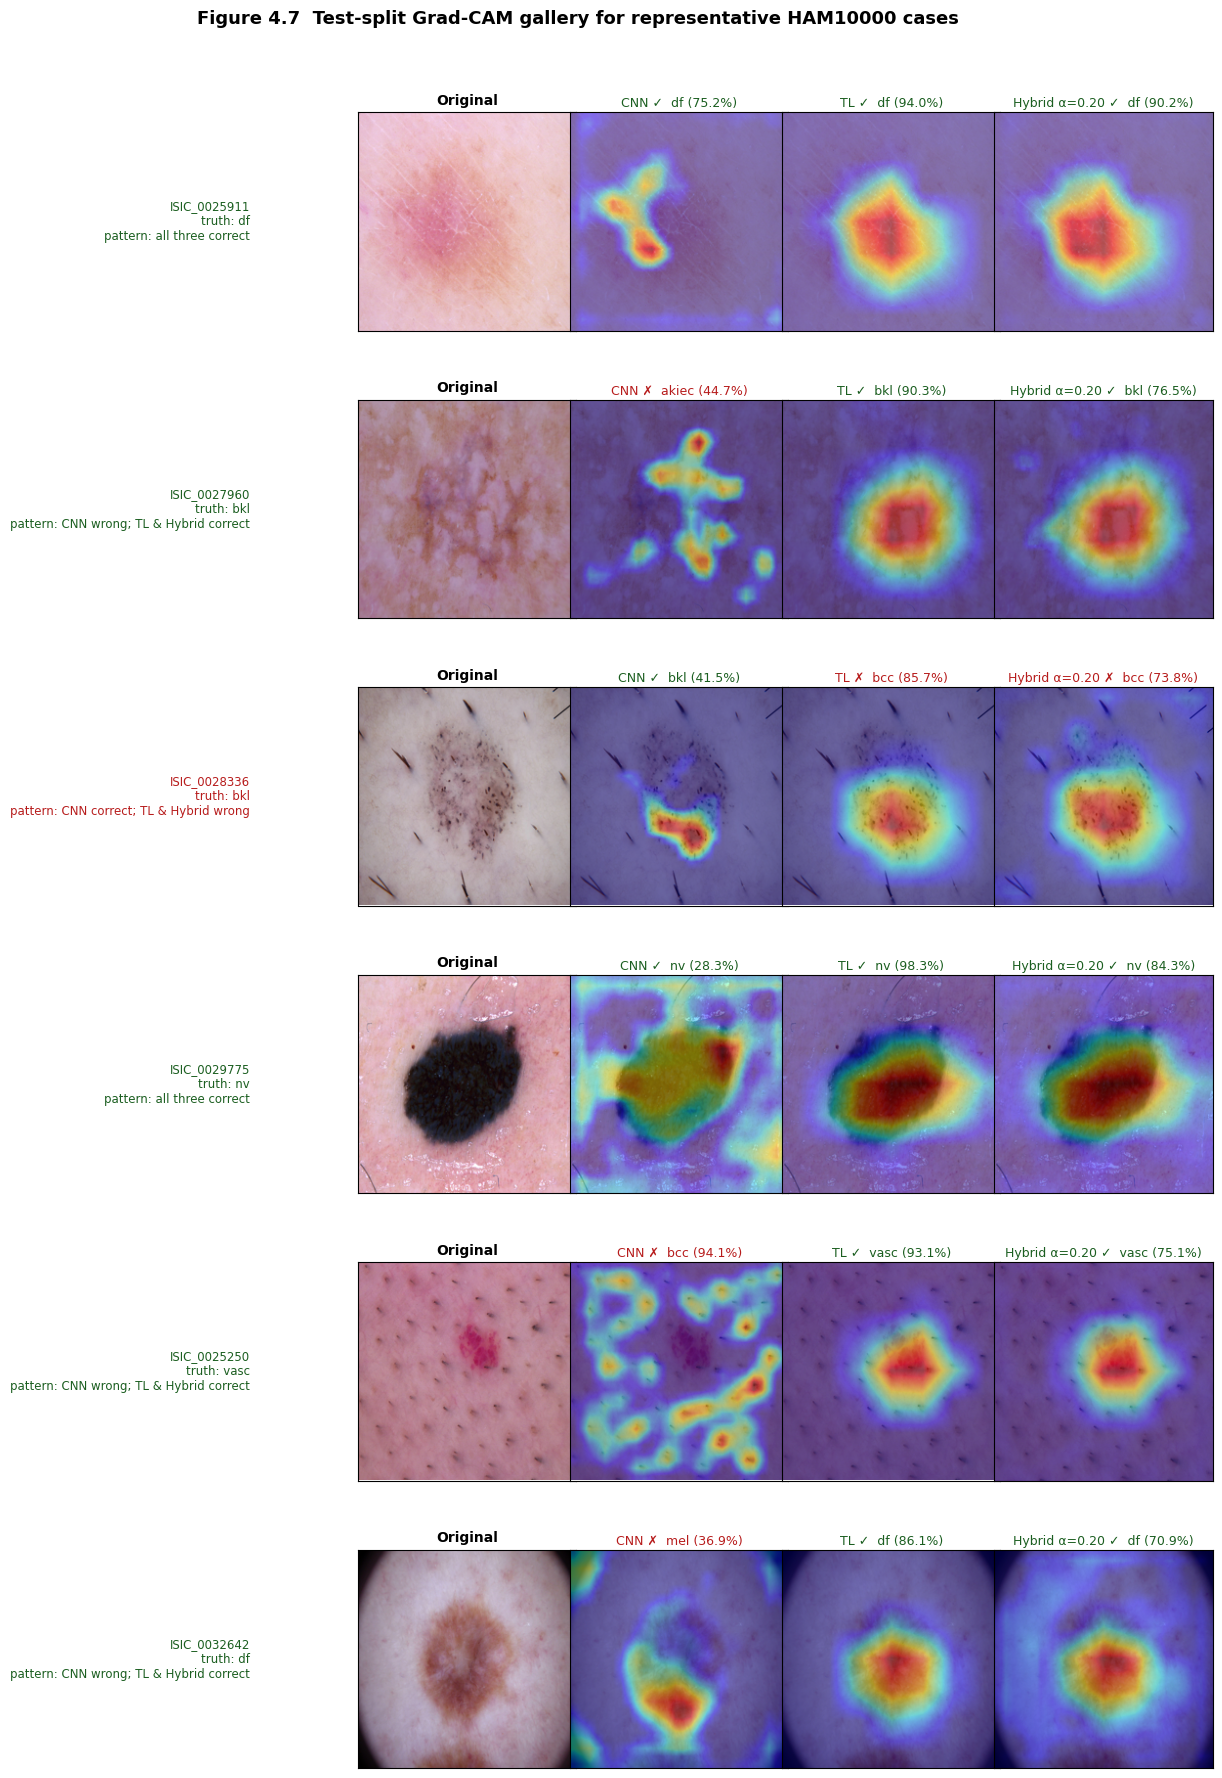

Saved figure: /content/Figure_4_7_test_split_gradcam_gallery.png


In [45]:
# ============================================================
# CELL B  (FIXED) — Figure 4.7 gallery (6 rows × 4 columns)
# Fix: gradcam_cnn / gradcam_resnet50 / gradcam_hybrid in your NB3
#      return TUPLES, not bare CAM arrays. Unpack them.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

OUT_DIR = '/content'

def overlay_cam(ax, pil_img_224, cam, title, title_color='black'):
    ax.imshow(pil_img_224)
    if cam is not None:
        ax.imshow(cam, cmap='jet', alpha=0.45)
    ax.set_title(title, fontsize=9, color=title_color, pad=4)
    ax.set_xticks([]); ax.set_yticks([])

n_rows = len(selected_rows)
fig, axes = plt.subplots(n_rows, 4, figsize=(13, 3.0 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for i, r in enumerate(selected_rows):
    img_path = r['path']
    pil = Image.open(img_path).convert('RGB').resize((224, 224))

    # ── Targeted Grad-CAMs ─────────────────────────────────────────────
    # Your NB3 helpers return tuples:
    #   gradcam_cnn       -> (cam, pred, probs)
    #   gradcam_resnet50  -> (cam, pred, probs)
    #   gradcam_hybrid    -> (cam_h, pred_h, probs_h, cam_cnn, cam_tl, pred_cnn, pred_tl)
    cam_cnn, _, _ = gradcam_cnn(cnn_model, pil,
                                class_idx=int(r['cnn_pred_idx']))
    cam_tl,  _, _ = gradcam_resnet50(tl_model, pil,
                                     class_idx=int(r['tl_pred_idx']))
    try:
        # gradcam_hybrid in your NB3 ignores class_idx for fusion
        # and returns 7 values; unpack only what we need.
        cam_hy, _, _, _, _, _, _ = gradcam_hybrid(
            cnn_model, tl_model, pil,
            alpha=best_alpha, class_idx=int(r['hy_pred_idx'])
        )
    except Exception:
        # Defensive fallback: blend at the same alpha
        cam_hy = best_alpha * cam_cnn + (1.0 - best_alpha) * cam_tl
        cam_hy = (cam_hy - cam_hy.min()) / (cam_hy.max() - cam_hy.min() + 1e-8)

    # Make sure every CAM is a clean 2-D float array (224×224)
    cam_cnn = np.asarray(cam_cnn, dtype=np.float32).squeeze()
    cam_tl  = np.asarray(cam_tl,  dtype=np.float32).squeeze()
    cam_hy  = np.asarray(cam_hy,  dtype=np.float32).squeeze()

    correct   = bool(r['hy_correct'])
    row_color = '#1B5E20' if correct else '#B71C1C'

    # column 0 — original image with row annotation on the left
    ax = axes[i, 0]
    ax.imshow(pil)
    left_label = (f"{r['image_id']}\n"
                  f"truth: {r['ground_truth_dx']}\n"
                  f"pattern: {r['pattern']}")
    ax.set_ylabel(left_label, fontsize=8.5, rotation=0, labelpad=78,
                  va='center', ha='right', color=row_color)
    ax.set_title('Original', fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    # columns 1-3 — CNN / TL / Hybrid CAMs
    cnn_mark = '✓' if r['cnn_correct'] else '✗'
    tl_mark  = '✓' if r['tl_correct']  else '✗'
    hy_mark  = '✓' if r['hy_correct']  else '✗'
    overlay_cam(axes[i, 1], pil, cam_cnn,
                f"CNN {cnn_mark}  {r['cnn_pred']} ({r['cnn_conf']*100:.1f}%)",
                title_color='#1B5E20' if r['cnn_correct'] else '#B71C1C')
    overlay_cam(axes[i, 2], pil, cam_tl,
                f"TL {tl_mark}  {r['tl_pred']} ({r['tl_conf']*100:.1f}%)",
                title_color='#1B5E20' if r['tl_correct'] else '#B71C1C')
    overlay_cam(axes[i, 3], pil, cam_hy,
                f"Hybrid α=0.20 {hy_mark}  {r['hy_pred']} ({r['hy_conf']*100:.1f}%)",
                title_color='#1B5E20' if r['hy_correct'] else '#B71C1C')

plt.suptitle('Figure 4.7  Test-split Grad-CAM gallery for representative HAM10000 cases',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.06, 0, 1, 0.985])

png_path = f'{OUT_DIR}/Figure_4_7_test_split_gradcam_gallery.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {png_path}")